In [1]:
import os
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from PIL import Image
import numpy as np

# === CONFIGURATION ===
input_dir = "data/images/ncd"      # dossier original des images NCD
output_dir = "data/images/ncd_aug" # dossier où seront stockées les nouvelles images
augment_per_image = 5              # combien de nouvelles images créer par image originale
img_height, img_width = 224, 224   # taille de ton modèle

# Créer le dossier de sortie
os.makedirs(output_dir, exist_ok=True)

# Définition des augmentations réalistes
datagen = ImageDataGenerator(
    rotation_range=25,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.15,
    horizontal_flip=True,
    vertical_flip=False,
    brightness_range=[0.8, 1.2],
    fill_mode='nearest'
)

# Charger toutes les images NCD
images = [f for f in os.listdir(input_dir) if f.lower().endswith(('.jpg', '.jpeg', '.png'))]

count = 0
for img_name in images:
    img_path = os.path.join(input_dir, img_name)
    img = Image.open(img_path).convert("RGB")
    img = img.resize((img_width, img_height))
    x = np.array(img)
    x = np.expand_dims(x, axis=0)  # (1, H, W, 3)

    # Génération d'images augmentées
    aug_iter = datagen.flow(x, batch_size=1, save_to_dir=output_dir,
                            save_prefix="aug", save_format="jpg")
    
    for _ in range(augment_per_image):
        next(aug_iter)
        count += 1

print(f"✅ Augmentation terminée : {count} nouvelles images créées dans {output_dir}")


c:\Users\Macky\Documents\Projet_St\Classification_d'images\.venv\Lib\site-packages\google\protobuf\runtime_version.py:98: UserWarning: Protobuf gencode version 5.28.3 is exactly one major version older than the runtime version 6.31.1 at tensorflow/core/framework/attr_value.proto. Please update the gencode to avoid compatibility violations in the next runtime release.
  warnings.warn(
c:\Users\Macky\Documents\Projet_St\Classification_d'images\.venv\Lib\site-packages\google\protobuf\runtime_version.py:98: UserWarning: Protobuf gencode version 5.28.3 is exactly one major version older than the runtime version 6.31.1 at tensorflow/core/framework/tensor.proto. Please update the gencode to avoid compatibility violations in the next runtime release.
  warnings.warn(
c:\Users\Macky\Documents\Projet_St\Classification_d'images\.venv\Lib\site-packages\google\protobuf\runtime_version.py:98: UserWarning: Protobuf gencode version 5.28.3 is exactly one major version older than the runtime version 6.3

✅ Augmentation terminée : 1880 nouvelles images créées dans data/images/ncd_aug


In [ ]:
data_dir = "data/images"

orig_ncd = len([f for f in os.listdir(os.path.join(data_dir, 'ncd'))
                if f.lower().endswith(('.jpg', '.jpeg', '.png'))])
aug_ncd = len([f for f in os.listdir(os.path.join(data_dir, 'ncd_aug'))
               if f.lower().endswith(('.jpg', '.jpeg', '.png'))])
total_ncd = orig_ncd + aug_ncd

print(f"Images originales ncd : {orig_ncd}")
print(f"Images augmentées dans ncd_aug : {aug_ncd}")
print(f"Total calculé ncd : {total_ncd}")

Images originales ncd : 376
Images augmentées dans ncd_aug : 1709
Total calculé ncd : 2085


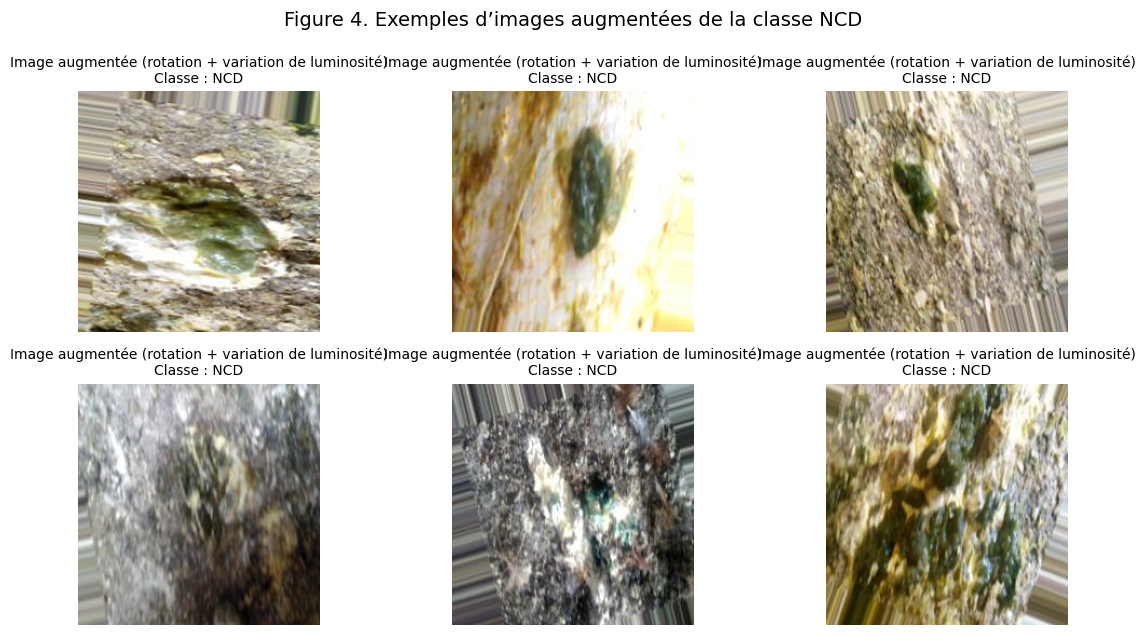

In [ ]:
import os
import random
from PIL import Image
import matplotlib.pyplot as plt

output_dir = "data/images/ncd_aug"

augmented_images = [f for f in os.listdir(output_dir) if f.lower().endswith(('.jpg', '.jpeg', '.png'))]

# Sélectionner aléatoirement quelques images augmentées
sample_images = random.sample(augmented_images, min(6, len(augmented_images)))

plt.figure(figsize=(12, 6))
for i, img_name in enumerate(sample_images):
    img_path = os.path.join(output_dir, img_name)
    img = Image.open(img_path)
    plt.subplot(2, 3, i + 1)
    plt.imshow(img)
    plt.axis("off")
    plt.title("Image augmentée (rotation + variation de luminosité)\nClasse : NCD", fontsize=10)

plt.tight_layout()
plt.suptitle("Figure 4. Exemples d’images augmentées de la classe NCD", fontsize=14, y=1.05)
plt.show()
